# Differentiable design of a pair-conversion tracker with an anticoincidence detector (ACD)

**Setup.** A monoenergetic photon beam hits the detector at normal incidence. The detector is a stack of
tungsten converter layers, each followed by two silicon strip planes (x and y), wrapped in a plastic
scintillator ACD that vetoes charged particles.

**Goal.** Choose the geometry that maximises the significance of a point-like signal on top of a diffuse
photon background and a charged-particle background.

**Method.** The whole detector response is a closed-form, differentiable function of the design parameters,
so JAX can give us the gradient of the significance with respect to every parameter and Adam can climb it.
All numbers are placeholders: set realistic ones before trusting any optimum.

**Naming.** camelCase everywhere, no unit suffixes. ACD is treated as a word (`acdThickness`).

**Units.** Lengths in cm, energies in MeV, times in s, solid angles in sr, fluxes in 1/(cm^2 s).
Angular variances are in rad^2. The angular resolution reported in the plots is in degrees.
Units are also given at the end of the line where each input is defined.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 64-bit floats: the significance formula subtracts large, similar numbers, and float32 loses precision there.
jax.config.update("jax_enable_x64", True)

## Fixed inputs
These are not optimised. If the optimiser could change them it would simply run to the bounds.

In [14]:
# Radiation lengths of the materials.
radiationLengthTungsten = 0.3504       # cm
radiationLengthSilicon = 9.37          # cm
radiationLengthScintillator = 42.4     # cm

# Pair conversion probability after x radiation lengths is 1 - exp(-7/9 * x), the high energy limit.
pairConversionCoefficientPerRadiationLength = 7.0 / 9.0

numberOfLayers = 10                    # Discrete, so it is scanned by hand rather than optimised.
photonEnergy = 100.0                   # MeV. Fixed because there is no calorimeter: energy is not a free measurement.
electronMass = 0.511                   # MeV
detectorSideLength = 40.0              # cm
siliconThickness = 0.03                # cm, thickness of one silicon plane.

# Fluxes and observation conditions.
signalPhotonFlux = 1e-3                # 1/(cm^2 s)
diffusePhotonFlux = 1e-2               # 1/(cm^2 s)
chargedParticleFlux = 1.0              # 1/(cm^2 s)
exposureDuration = 1e4                 # s
fieldOfViewSolidAngle = 1.0            # sr

# Constraints that keep the optimum finite. Without them the optimiser drives the strip pitch to its
# lower bound and makes the detector as tall and channel-rich as allowed.
channelBudget = 5e4                    # number of strips
maximumHeight = 30.0                   # cm

# A track needs hits in the layers below the conversion point to be reconstructed.
minimumDownstreamLayersForReconstruction = 3

# Multiple scattering: scattering in downstream material is counted with this reduced weight (toy value).
downstreamScatteringWeight = 1.0 / 3.0

# Signal region: a cone around the source with this radius, in units of the angular resolution.
signalConeRadiusInSigma = 2.0

# Plastic scintillator ACD.
minimumIonisingEnergyLossPerLength = 1.95   # MeV/cm, energy deposited by a minimum ionising particle.
maximumVetoEfficiency = 0.999
vetoTurnOnWidthFraction = 0.25         # Width of the efficiency turn-on, as a fraction of the deposit.
accidentalVetoScale = 0.1              # MeV. Sets how fast noise-induced dead time falls with threshold.

# Allowed range of each free parameter. Optimisation runs in an unbounded space (see below).
parameterBounds = {
    "converterThickness": (0.0, 0.2),    # cm, one value per layer.
    "layerSpacing": (0.5, 5.0),            # cm
    "stripPitch": (0.005, 0.1),            # cm
    "acdThickness": (0.5, 3.0),            # cm
    "acdThreshold": (0.05, 1.0),           # MeV
}

## Detector model

The optimiser works on *unbounded* numbers. A sigmoid maps each one into its allowed range, so the
parameters can never leave the physical region and no clipping (which has zero gradient) is needed.

In [15]:
def mapUnboundedToRange(unboundedValue, lowerBound, upperBound):
    return lowerBound + (upperBound - lowerBound) * jax.nn.sigmoid(unboundedValue)


def mapUnboundedToPhysicalParameters(unboundedParameters):
    return {
        parameterName: mapUnboundedToRange(unboundedParameters[parameterName], *parameterBounds[parameterName])
        for parameterName in parameterBounds
    }

In [16]:
# Layers below each layer, used both to decide if a track can be reconstructed and for the lever arm.
numberOfLayersBelow = numberOfLayers - 1 - jnp.arange(numberOfLayers)


def computeLayerMaterial(converterThickness):
    """Material in each layer, and above and below it, in radiation lengths."""
    # Material in one layer: tungsten converter plus one silicon plane.
    converterRadiationLengths = converterThickness / radiationLengthTungsten
    radiationLengthsPerLayer = converterRadiationLengths + siliconThickness / radiationLengthSilicon

    # Material the photon crosses before reaching a layer, and material the pair crosses after leaving it.
    radiationLengthsAboveLayer = jnp.cumsum(radiationLengthsPerLayer) - radiationLengthsPerLayer
    radiationLengthsBelowLayer = jnp.sum(radiationLengthsPerLayer) - jnp.cumsum(radiationLengthsPerLayer)
    return converterRadiationLengths, radiationLengthsAboveLayer, radiationLengthsBelowLayer


def computeConversionProbabilityPerLayer(converterRadiationLengths, radiationLengthsAboveLayer):
    """Probability that the photon converts in each layer and leaves a reconstructable track."""
    hasEnoughDownstreamLayers = (numberOfLayersBelow >= minimumDownstreamLayersForReconstruction).astype(float)

    # Photon survives the layers above, then converts in this layer's tungsten. Silicon is ignored as a converter.
    return (
        jnp.exp(-pairConversionCoefficientPerRadiationLength * radiationLengthsAboveLayer)
        * (1.0 - jnp.exp(-pairConversionCoefficientPerRadiationLength * converterRadiationLengths))
        * hasEnoughDownstreamLayers
    )


def computeEffectiveAngularVariance(
    converterRadiationLengths, radiationLengthsBelowLayer, conversionProbabilityPerLayer, layerSpacing, stripPitch
):
    """Angular variance (rad^2) of the reconstructed direction, averaged over conversion layers."""
    # Three independent contributions, added in quadrature (variances in rad^2), evaluated per conversion layer.
    # 1. Multiple scattering (Highland formula without the log term). Each pair member carries half the energy.
    #    The conversion happens on average halfway through its own converter.
    radiationLengthsTraversedByPair = (
        0.5 * converterRadiationLengths + downstreamScatteringWeight * radiationLengthsBelowLayer
    )
    multipleScatteringVariance = (13.6 / (photonEnergy / 2.0)) ** 2 * radiationLengthsTraversedByPair
    # 2. Intrinsic opening angle of the pair.
    pairOpeningAngleVariance = (electronMass / photonEnergy) ** 2
    # 3. Strip resolution (pitch / sqrt(12) for a uniform hit distribution) over the lever arm to the last layer.
    leverArm = jnp.maximum(numberOfLayersBelow, 1) * layerSpacing   # cm
    stripResolutionVariance = 2.0 * (stripPitch / jnp.sqrt(12.0) / leverArm) ** 2

    angularVariancePerLayer = multipleScatteringVariance + pairOpeningAngleVariance + stripResolutionVariance
    # Average over conversion layers, weighted by how likely each layer is to be the conversion layer.
    return jnp.sum(conversionProbabilityPerLayer * angularVariancePerLayer) / jnp.sum(conversionProbabilityPerLayer)


def computeSignalConeFractions(effectiveAngularVariance):
    """How much signal the signal cone keeps, and how much of the background it lets in."""
    signalConeSolidAngle = jnp.pi * signalConeRadiusInSigma**2 * effectiveAngularVariance   # sr
    backgroundFractionInsideCone = signalConeSolidAngle / fieldOfViewSolidAngle
    # Fraction of a 2D Gaussian inside a circle of the given radius in sigma.
    signalContainmentFraction = 1.0 - jnp.exp(-(signalConeRadiusInSigma**2) / 2.0)
    return signalContainmentFraction, backgroundFractionInsideCone


def computeAcdResponse(acdThickness, acdThreshold):
    """Charged-particle veto efficiency, photon survival through the ACD, and livetime lost to noise."""
    energyDepositedInAcd = minimumIonisingEnergyLossPerLength * acdThickness   # MeV
    # Smooth turn-on of the charged-particle detection efficiency around the threshold.
    vetoEfficiency = maximumVetoEfficiency * jax.nn.sigmoid(
        (energyDepositedInAcd - acdThreshold) / (vetoTurnOnWidthFraction * energyDepositedInAcd)
    )
    # A photon that converts inside the ACD is vetoed by mistake ("self-veto"), so a thick ACD costs signal.
    photonSurvivalProbabilityThroughAcd = jnp.exp(
        -pairConversionCoefficientPerRadiationLength * acdThickness / radiationLengthScintillator
    )
    # Low thresholds trigger the veto on noise, which removes livetime. Toy model, falls exponentially.
    livetimeFraction = jnp.exp(-jnp.exp(-acdThreshold / accidentalVetoScale))
    return vetoEfficiency, photonSurvivalProbabilityThroughAcd, livetimeFraction


def computeExpectedCounts(
    totalConversionProbability, signalContainmentFraction, backgroundFractionInsideCone,
    vetoEfficiency, photonSurvivalProbabilityThroughAcd, livetimeFraction,
):
    """Expected signal and background counts over the exposure."""
    detectorArea = detectorSideLength**2   # cm^2
    exposureFactor = detectorArea * exposureDuration * livetimeFraction

    signalCount = (
        signalPhotonFlux * exposureFactor * totalConversionProbability
        * photonSurvivalProbabilityThroughAcd * signalContainmentFraction
    )
    # Two backgrounds: diffuse photons that convert like the signal, and charged particles the veto misses.
    backgroundCount = exposureFactor * backgroundFractionInsideCone * (
        diffusePhotonFlux * totalConversionProbability * photonSurvivalProbabilityThroughAcd
        + chargedParticleFlux * (1.0 - vetoEfficiency)
    )
    return signalCount, backgroundCount


def computeConstraintPenalty(stripPitch, layerSpacing):
    """Channel and height budgets, as smooth penalties that are zero while satisfied."""
    numberOfChannels = 2 * numberOfLayers * detectorSideLength / stripPitch    # x and y strips.
    totalHeight = (numberOfLayers - 1) * layerSpacing   # cm
    constraintPenalty = (
        jax.nn.relu(numberOfChannels / channelBudget - 1.0) ** 2
        + jax.nn.relu(totalHeight / maximumHeight - 1.0) ** 2
    )
    return constraintPenalty, numberOfChannels


def computeDetectorResponse(unboundedParameters):
    """Expected signal and background counts for a design, plus diagnostics. Fully differentiable."""
    physicalParameters = mapUnboundedToPhysicalParameters(unboundedParameters)
    converterThickness = physicalParameters["converterThickness"]      # Vector, one entry per layer.
    layerSpacing = physicalParameters["layerSpacing"]
    stripPitch = physicalParameters["stripPitch"]
    acdThickness = physicalParameters["acdThickness"]
    acdThreshold = physicalParameters["acdThreshold"]

    converterRadiationLengths, radiationLengthsAboveLayer, radiationLengthsBelowLayer = computeLayerMaterial(converterThickness)
    conversionProbabilityPerLayer = computeConversionProbabilityPerLayer(converterRadiationLengths, radiationLengthsAboveLayer)
    totalConversionProbability = conversionProbabilityPerLayer.sum()
    effectiveAngularVariance = computeEffectiveAngularVariance(
        converterRadiationLengths, radiationLengthsBelowLayer, conversionProbabilityPerLayer, layerSpacing, stripPitch
    )
    signalContainmentFraction, backgroundFractionInsideCone = computeSignalConeFractions(effectiveAngularVariance)
    vetoEfficiency, photonSurvivalProbabilityThroughAcd, livetimeFraction = computeAcdResponse(acdThickness, acdThreshold)
    signalCount, backgroundCount = computeExpectedCounts(
        totalConversionProbability, signalContainmentFraction, backgroundFractionInsideCone,
        vetoEfficiency, photonSurvivalProbabilityThroughAcd, livetimeFraction,
    )
    constraintPenalty, numberOfChannels = computeConstraintPenalty(stripPitch, layerSpacing)

    return dict(
        signalCount=signalCount,
        backgroundCount=backgroundCount,
        constraintPenalty=constraintPenalty,
        totalConversionProbability=totalConversionProbability,
        angularResolution=jnp.degrees(jnp.sqrt(effectiveAngularVariance)),
        vetoEfficiency=vetoEfficiency,
        numberOfChannels=numberOfChannels,
        conversionProbabilityPerLayer=conversionProbabilityPerLayer,
    )


def computeAsimovSignificance(signalCount, backgroundCount):
    # Median discovery significance for a counting experiment, valid also when the counts are small.
    return jnp.sqrt(2.0 * ((signalCount + backgroundCount) * jnp.log1p(signalCount / backgroundCount) - signalCount))


def computeLoss(unboundedParameters):
    detectorResponse = computeDetectorResponse(unboundedParameters)
    significance = computeAsimovSignificance(detectorResponse["signalCount"], detectorResponse["backgroundCount"])
    # Log of the significance keeps gradients well scaled over orders of magnitude; the penalty enforces the budgets.
    return -jnp.log(significance) + 10.0 * detectorResponse["constraintPenalty"]


scalarMetricNames = (
    "significance", "signalCount", "backgroundCount", "constraintPenalty",
    "totalConversionProbability", "angularResolution", "vetoEfficiency", "numberOfChannels",
)


@jax.jit
def computeMetrics(unboundedParameters):
    detectorResponse = computeDetectorResponse(unboundedParameters)
    detectorResponse["significance"] = computeAsimovSignificance(detectorResponse["signalCount"], detectorResponse["backgroundCount"])
    return detectorResponse

## Optimisation, recording the history
Every `recordingInterval` steps we store the metrics and the physical parameters, for the plots below.

In [22]:
def createInitialParameters(randomKey=None, randomSpread=0.0):
    """Zeros put every parameter at the middle of its range. A random key gives a random starting design."""
    if randomKey is None:
        return {
            "converterThickness": jnp.zeros(numberOfLayers),
            "layerSpacing": 1.1,
            "stripPitch": 1.1,
            "acdThickness": 1.1,
            "acdThreshold": 1.1,
        }
    keyForConverter, keyForSpacing, keyForPitch, keyForAcd, keyForThreshold = jax.random.split(randomKey, 5)
    return {
        "converterThickness": randomSpread * jax.random.normal(keyForConverter, (numberOfLayers,)),
        "layerSpacing": randomSpread * jax.random.normal(keyForSpacing),
        "stripPitch": randomSpread * jax.random.normal(keyForPitch),
        "acdThickness": randomSpread * jax.random.normal(keyForAcd),
        "acdThreshold": randomSpread * jax.random.normal(keyForThreshold),
    }


def runOptimisation(initialParameters, numberOfSteps=2000, learningRate=5e-2, recordingInterval=10):
    optimiser = optax.adam(learningRate)
    optimiserState = optimiser.init(initialParameters)

    @jax.jit
    def performOneStep(currentParameters, currentOptimiserState):
        lossValue, gradients = jax.value_and_grad(computeLoss)(currentParameters)   # Autodiff happens here.
        parameterUpdates, newOptimiserState = optimiser.update(gradients, currentOptimiserState)
        return optax.apply_updates(currentParameters, parameterUpdates), newOptimiserState

    currentParameters = initialParameters
    recordedHistory = {"loss": [], "physicalParameters": [], "metrics": []}
    for stepNumber in range(numberOfSteps):
        if stepNumber % recordingInterval == 0:
            metricsAtStep = computeMetrics(currentParameters)
            recordedHistory["metrics"].append({metricName: float(metricsAtStep[metricName]) for metricName in scalarMetricNames})
            recordedHistory["physicalParameters"].append(
                {parameterName: np.array(parameterValue) for parameterName, parameterValue in mapUnboundedToPhysicalParameters(currentParameters).items()}
            )
            recordedHistory["loss"].append(float(computeLoss(currentParameters)))
        currentParameters, optimiserState = performOneStep(currentParameters, optimiserState)
    return currentParameters, recordedHistory


recordingInterval = 10
initialParameters = createInitialParameters()
optimisedParameters, optimisationHistory = runOptimisation(initialParameters, recordingInterval=recordingInterval)

initialMetrics = optimisationHistory["metrics"][0]
finalMetrics = {metricName: float(metricValue) for metricName, metricValue in computeMetrics(optimisedParameters).items() if metricValue.ndim == 0}
print(
    f"significance {initialMetrics['significance']:.2f} -> {finalMetrics['significance']:.2f}   "
    f"signal {finalMetrics['signalCount']:.1f}   background {finalMetrics['backgroundCount']:.1f}   "
    f"angular resolution {finalMetrics['angularResolution']:.2f} deg"
)

significance 14.50 -> 21.53   signal 7709.5   background 125724.9   angular resolution 8.65 deg


In [23]:
optimisedParameters

{'acdThickness': Array(6.67448755, dtype=float64),
 'acdThreshold': Array(-1.03208235, dtype=float64),
 'converterThickness': Array([-1.0680649 , -0.98655407, -0.89955699, -0.80583318, -0.70377786,
        -0.59125797, -0.46534724, -8.70466966, -8.70466966, -8.70466966],      dtype=float64),
 'layerSpacing': Array(0.17818762, dtype=float64),
 'stripPitch': Array(-2.0154729, dtype=float64)}

In [24]:
mapUnboundedToPhysicalParameters(optimisedParameters)

{'converterThickness': Array([5.11542523e-02, 5.43186502e-02, 5.78283087e-02, 6.17558262e-02,
        6.61950322e-02, 7.12692538e-02, 7.71436157e-02, 3.31564473e-05,
        3.31564473e-05, 3.31564473e-05], dtype=float64),
 'layerSpacing': Array(2.94993235, dtype=float64),
 'stripPitch': Array(0.01617085, dtype=float64),
 'acdThickness': Array(2.99684718, dtype=float64),
 'acdThreshold': Array(0.29954657, dtype=float64)}

## Performance evolution

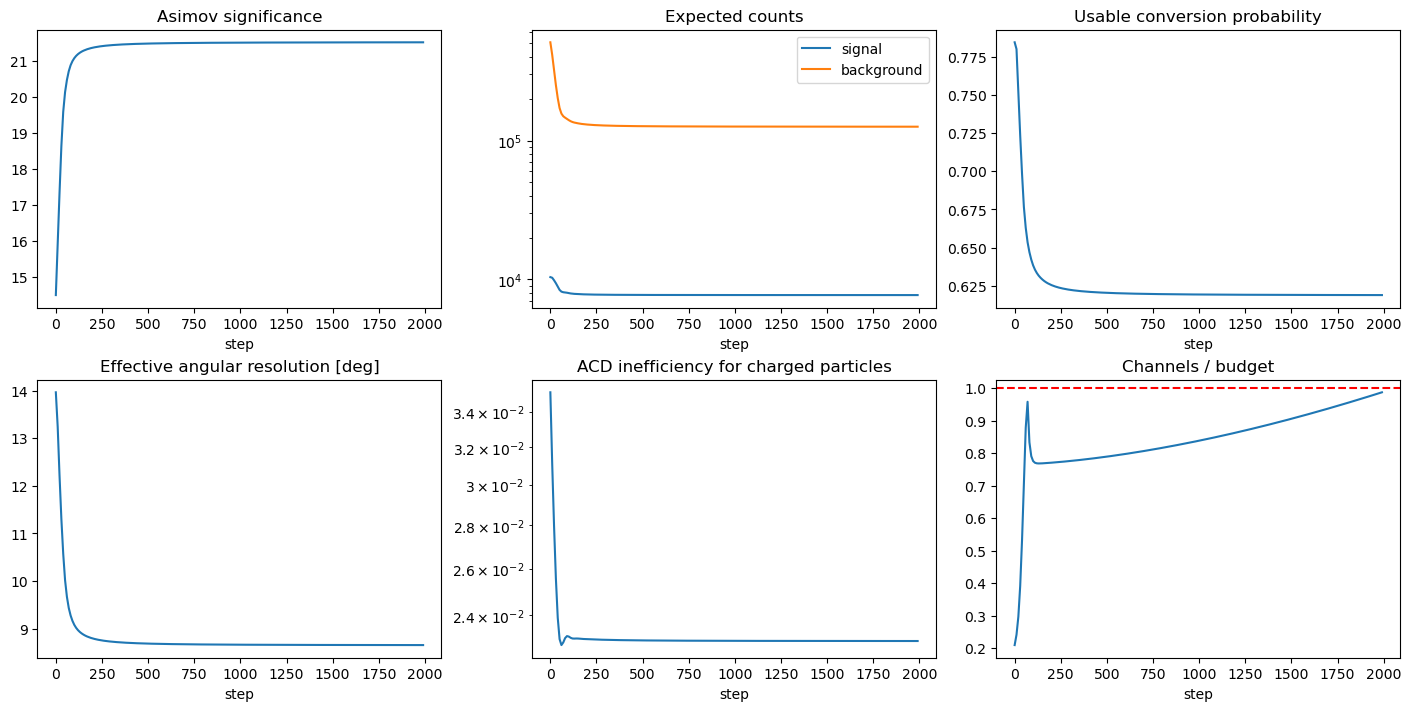

In [25]:
stepNumbers = np.arange(len(optimisationHistory["metrics"])) * recordingInterval
metricsOverSteps = {
    metricName: np.array([recordedEntryAtStep[metricName] for recordedEntryAtStep in optimisationHistory["metrics"]]) for metricName in scalarMetricNames
}

performanceFigure, axesGrid = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
significanceAxis, countsAxis, conversionAxis = axesGrid[0]
resolutionAxis, vetoInefficiencyAxis, channelAxis = axesGrid[1]

significanceAxis.plot(stepNumbers, metricsOverSteps["significance"])
significanceAxis.set(title="Asimov significance", xlabel="step")

countsAxis.plot(stepNumbers, metricsOverSteps["signalCount"], label="signal")
countsAxis.plot(stepNumbers, metricsOverSteps["backgroundCount"], label="background")
countsAxis.set(yscale="log", title="Expected counts", xlabel="step")
countsAxis.legend()

conversionAxis.plot(stepNumbers, metricsOverSteps["totalConversionProbability"])
conversionAxis.set(title="Usable conversion probability", xlabel="step")

resolutionAxis.plot(stepNumbers, metricsOverSteps["angularResolution"])
resolutionAxis.set(title="Effective angular resolution [deg]", xlabel="step")

vetoInefficiencyAxis.plot(stepNumbers, 1.0 - metricsOverSteps["vetoEfficiency"])
vetoInefficiencyAxis.set(yscale="log", title="ACD inefficiency for charged particles", xlabel="step")

channelAxis.plot(stepNumbers, metricsOverSteps["numberOfChannels"] / channelBudget)
channelAxis.axhline(1.0, color="red", linestyle="--")   # Above this line the channel budget is violated.
channelAxis.set(title="Channels / budget", xlabel="step")
plt.show()

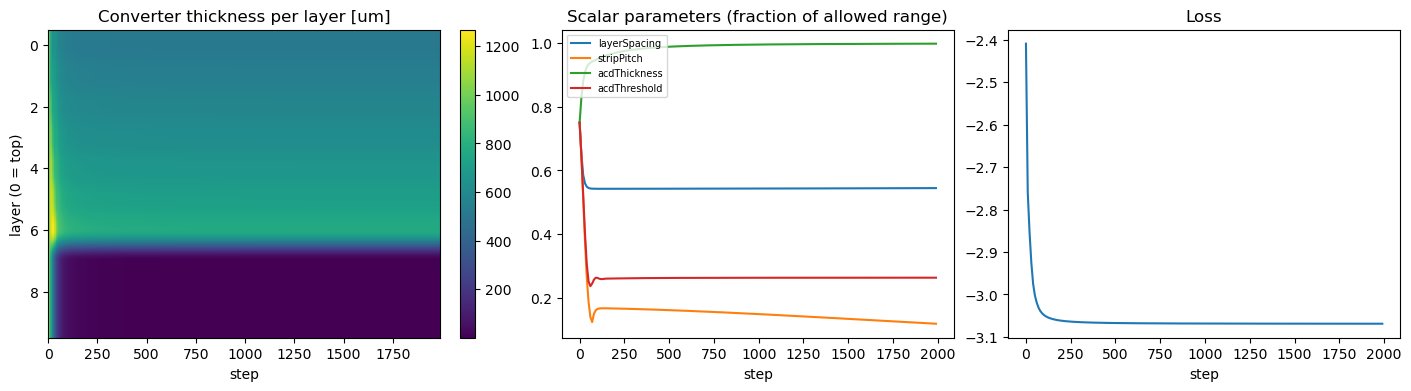

In [26]:
# How the parameters moved. Scalars are shown as a fraction of their allowed range so they share one drawingAxis.
converterThicknessHistory = np.array(
    [recordedEntryAtStep["converterThickness"] for recordedEntryAtStep in optimisationHistory["physicalParameters"]]
)
parameterFigure, (heatmapAxis, scalarParameterAxis, lossAxis) = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)

micrometersPerCentimeter = 1e4
heatmapImage = heatmapAxis.imshow(
    converterThicknessHistory.T * micrometersPerCentimeter, aspect="auto", origin="lower",
    extent=[0, stepNumbers[-1], -0.5, numberOfLayers - 0.5],
)
heatmapAxis.set(title="Converter thickness per layer [um]", xlabel="step", ylabel="layer (0 = top)")
heatmapAxis.invert_yaxis()
plt.colorbar(heatmapImage, ax=heatmapAxis)

for parameterName in ("layerSpacing", "stripPitch", "acdThickness", "acdThreshold"):
    parameterOverSteps = np.array([recordedEntryAtStep[parameterName] for recordedEntryAtStep in optimisationHistory["physicalParameters"]])
    lowerBound, upperBound = parameterBounds[parameterName]
    scalarParameterAxis.plot(stepNumbers, (parameterOverSteps - lowerBound) / (upperBound - lowerBound), label=parameterName)
scalarParameterAxis.set(title="Scalar parameters (fraction of allowed range)", xlabel="step")
scalarParameterAxis.legend(fontsize=7)

lossAxis.plot(stepNumbers, optimisationHistory["loss"])
lossAxis.set(title="Loss", xlabel="step")
plt.show()

## Design views
Converter thickness is drawn 10x thicker than real so it is visible. The ACD is drawn to scale.

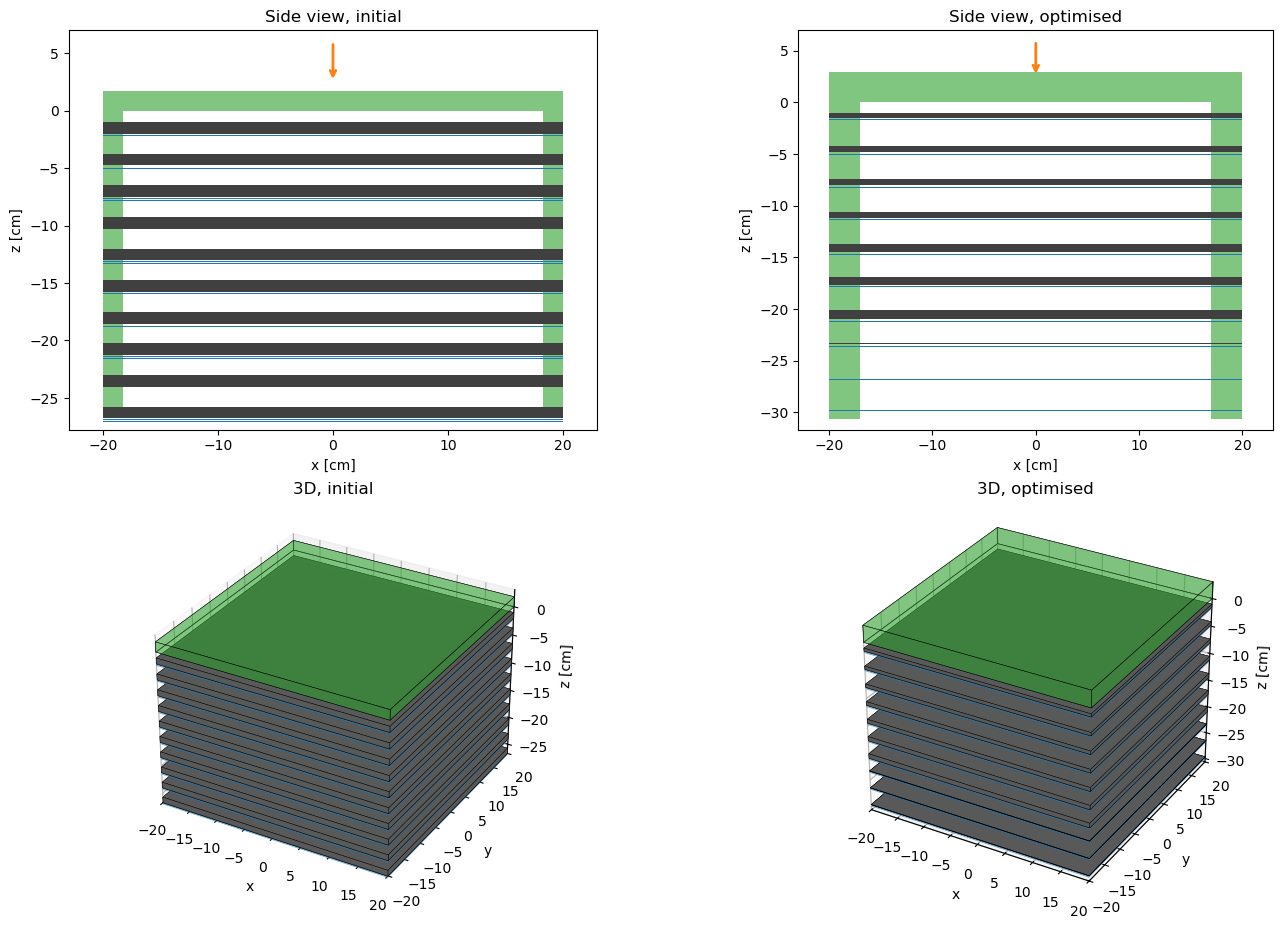

In [8]:
converterDrawingExaggeration = 10.0
siliconPlaneDrawnGap = 0.15         # Distance between the converter and the silicon planes, for drawing only.
siliconPlaneDrawnThickness = 0.05
firstLayerDepth = 1.0               # Gap between the top of the ACD and the first converter.
bottomMargin = 1.0


def computeDrawingGeometry(physicalParameters):
    layerSpacing = float(physicalParameters["layerSpacing"])
    return dict(
        converterDrawnThickness=np.array(physicalParameters["converterThickness"]) * converterDrawingExaggeration,
        acdThickness=float(physicalParameters["acdThickness"]),
        enclosureHeight=firstLayerDepth + (numberOfLayers - 1) * layerSpacing + bottomMargin,
        converterTopHeights=-firstLayerDepth - np.arange(numberOfLayers) * layerSpacing,   # Beam enters at z = 0.
    )


def drawSideView(drawingAxis, physicalParameters, title):
    drawingGeometry = computeDrawingGeometry(physicalParameters)
    halfSide = detectorSideLength / 2.0
    acdThickness = drawingGeometry["acdThickness"]
    enclosureHeight = drawingGeometry["enclosureHeight"]

    # ACD: one plate on top and one on each side.
    drawingAxis.add_patch(Rectangle((-halfSide, 0), detectorSideLength, acdThickness, facecolor="tab:green", alpha=0.6))
    drawingAxis.add_patch(Rectangle((-halfSide, -enclosureHeight), acdThickness, enclosureHeight, facecolor="tab:green", alpha=0.6))
    drawingAxis.add_patch(Rectangle((halfSide - acdThickness, -enclosureHeight), acdThickness, enclosureHeight, facecolor="tab:green", alpha=0.6))

    for layerIndex, converterTop in enumerate(drawingGeometry["converterTopHeights"]):
        converterThicknessDrawn = drawingGeometry["converterDrawnThickness"][layerIndex]
        drawingAxis.add_patch(Rectangle((-halfSide, converterTop - converterThicknessDrawn), detectorSideLength, converterThicknessDrawn, facecolor="0.25"))
        # Two silicon planes (x and y strips) below each converter.
        for planeNumber in (1, 2):
            planeBottom = converterTop - converterThicknessDrawn - planeNumber * siliconPlaneDrawnGap
            drawingAxis.add_patch(Rectangle((-halfSide, planeBottom), detectorSideLength, siliconPlaneDrawnThickness, facecolor="tab:blue"))

    drawingAxis.annotate("", xy=(0, 2.5), xytext=(0, 6), arrowprops=dict(arrowstyle="->", color="tab:orange", lw=2))   # Beam.
    drawingAxis.set(xlim=(-halfSide - 3, halfSide + 3), ylim=(-enclosureHeight - 1, 7), aspect="equal",
             title=title, xlabel="x [cm]", ylabel="z [cm]")


def createBoxFaces(xMin, xMax, yMin, yMax, zMin, zMax):
    cornerCoordinates = np.array([
        [xMin, yMin, zMin], [xMax, yMin, zMin], [xMax, yMax, zMin], [xMin, yMax, zMin],
        [xMin, yMin, zMax], [xMax, yMin, zMax], [xMax, yMax, zMax], [xMin, yMax, zMax],
    ])
    faceCornerIndexSets = [[0, 1, 2, 3], [4, 5, 6, 7], [0, 1, 5, 4], [2, 3, 7, 6], [1, 2, 6, 5], [0, 3, 7, 4]]
    return [[cornerCoordinates[cornerIndex] for cornerIndex in cornerIndicesOfFace] for cornerIndicesOfFace in faceCornerIndexSets]


def drawThreeDimensionalView(drawingAxis, physicalParameters, title):
    drawingGeometry = computeDrawingGeometry(physicalParameters)
    halfSide = detectorSideLength / 2.0
    enclosureHeight = drawingGeometry["enclosureHeight"]

    for layerIndex, converterTop in enumerate(drawingGeometry["converterTopHeights"]):
        converterThicknessDrawn = drawingGeometry["converterDrawnThickness"][layerIndex]
        converterBottom = converterTop - converterThicknessDrawn
        drawingAxis.add_collection3d(Poly3DCollection(
            createBoxFaces(-halfSide, halfSide, -halfSide, halfSide, converterBottom, converterTop),
            facecolor="0.35", edgecolor="black", linewidth=0.3, alpha=0.9))
        drawingAxis.add_collection3d(Poly3DCollection(
            createBoxFaces(-halfSide, halfSide, -halfSide, halfSide, converterBottom - 0.3, converterBottom - 0.2),
            facecolor="tab:blue", alpha=0.4))

    # Only the top ACD plate is drawn: the side plates would hide the tracker.
    drawingAxis.add_collection3d(Poly3DCollection(
        createBoxFaces(-halfSide, halfSide, -halfSide, halfSide, 0, drawingGeometry["acdThickness"]),
        facecolor="tab:green", edgecolor="black", linewidth=0.3, alpha=0.35))

    drawingAxis.set(xlim=(-halfSide, halfSide), ylim=(-halfSide, halfSide), zlim=(-enclosureHeight, 3),
             title=title, xlabel="x", ylabel="y", zlabel="z [cm]")
    drawingAxis.set_box_aspect((detectorSideLength, detectorSideLength, enclosureHeight + 3))
    drawingAxis.quiver(0, 0, 8, 0, 0, -6, color="tab:orange", linewidth=2)   # Beam.


initialPhysicalParameters = mapUnboundedToPhysicalParameters(initialParameters)
optimisedPhysicalParameters = mapUnboundedToPhysicalParameters(optimisedParameters)

designFigure = plt.figure(figsize=(14, 9), constrained_layout=True)
for columnIndex, (designParameters, designName) in enumerate(
    [(initialPhysicalParameters, "initial"), (optimisedPhysicalParameters, "optimised")]
):
    drawSideView(designFigure.add_subplot(2, 2, 1 + columnIndex), designParameters, f"Side view, {designName}")
    drawThreeDimensionalView(designFigure.add_subplot(2, 2, 3 + columnIndex, projection="3d"), designParameters, f"3D, {designName}")
plt.show()

## Per-layer comparison

In [ ]:
initialResponse = computeMetrics(initialParameters)
optimisedResponse = computeMetrics(optimisedParameters)

layerNumbers = np.arange(numberOfLayers)
barWidth = 0.4
perLayerFigure, (thicknessAxis, conversionPerLayerAxis) = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)

thicknessAxis.bar(layerNumbers - barWidth / 2, np.array(initialPhysicalParameters["converterThickness"]) * micrometersPerCentimeter, barWidth, label="initial")
thicknessAxis.bar(layerNumbers + barWidth / 2, np.array(optimisedPhysicalParameters["converterThickness"]) * micrometersPerCentimeter, barWidth, label="optimised")
thicknessAxis.set(title="Converter thickness [um]", xlabel="layer")
thicknessAxis.legend()

conversionPerLayerAxis.bar(layerNumbers - barWidth / 2, initialResponse["conversionProbabilityPerLayer"], barWidth, label="initial")
conversionPerLayerAxis.bar(layerNumbers + barWidth / 2, optimisedResponse["conversionProbabilityPerLayer"], barWidth, label="optimised")
conversionPerLayerAxis.set(title="Usable conversion probability per layer", xlabel="layer")
conversionPerLayerAxis.legend()
plt.show()

## Random restarts
The landscape can have several local optima, so start from random designs and compare the final significance.

In [ ]:
numberOfRestarts = 6
restartResults = []
for seedNumber in range(numberOfRestarts):
    restartParameters, restartHistory = runOptimisation(
        createInitialParameters(jax.random.PRNGKey(seedNumber), randomSpread=1.5), numberOfSteps=1500
    )
    restartResults.append((float(computeMetrics(restartParameters)["significance"]), restartHistory))

restartFigure, restartAxis = plt.subplots(figsize=(6, 3.5))
for finalSignificance, restartHistory in restartResults:
    restartAxis.plot(
        np.arange(len(restartHistory["metrics"])) * recordingInterval,
        [recordedEntryAtStep["significance"] for recordedEntryAtStep in restartHistory["metrics"]],
        label=f"final {finalSignificance:.2f}",
    )
restartAxis.set(xlabel="step", ylabel="significance", title="Random restarts")
restartAxis.legend(fontsize=7)
plt.show()